找到 1 个.mat文件
正在加载: Load_Strain_random_normal.mat
使用键名: load='load_data', strain='strain_data'
  载荷数据形状: (1, 1309696)
  应变数据形状: (10, 1309696)

合并后的数据形状:
载荷数据: (1, 1309696)
应变数据: (10, 1309696)
当前 notebook 文件所在目录为: /root/shared-nvme/SSH_remote/20250804LoadingIdentification
应变窗口形状: (1278, 2048, 10)
载荷窗口形状: (1278, 2048, 1)
Transformer模型总参数数量: 18,920,449
模型结构:
TransformerModel(
  (input_projection): Linear(in_features=10, out_features=512, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementw

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

保存最佳Transformer模型，验证损失: 0.985318
训练损失历史已保存到 transformer_loss_history.json


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

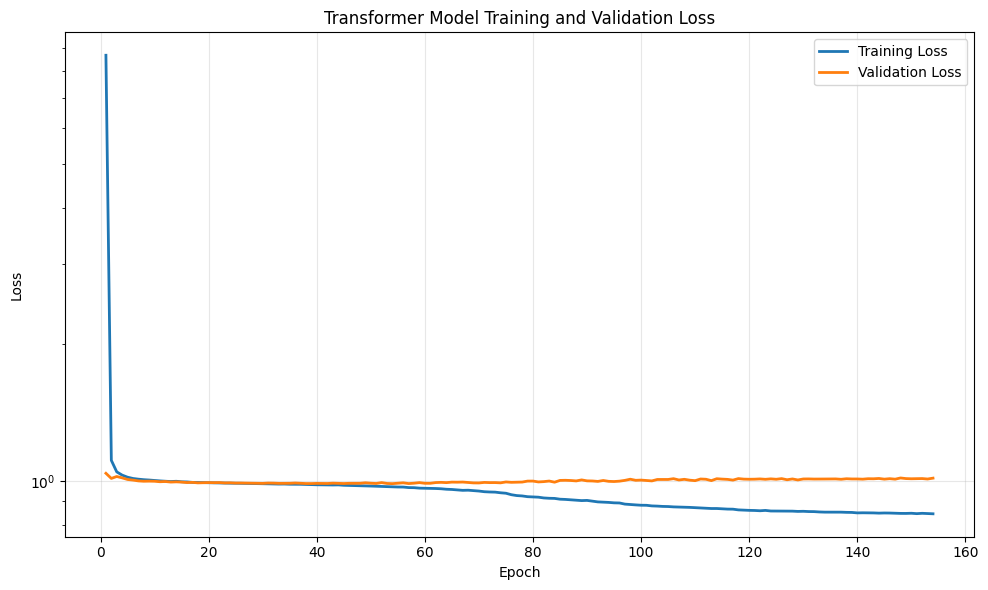


所有任务完成！
生成的文件:
- best_transformer_model.pth: 最佳模型权重
- best_transformer_model_dwell.pth: 完整模型信息
- transformer_evaluation_metrics.json: 评估指标
- transformer_loss_history.json: 训练历史
- transformer_training_loss.png: 损失曲线图
- strain_scaler.save: 应变数据标准化器
- load_scaler.save: 载荷数据标准化器


In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import joblib
import math
import json
from matplotlib import rcParams

# 设置中文字体（这里以SimHei字体为例）
rcParams['font.sans-serif'] = ['SimHei']  # 指定中文字体
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

def load_mat_files_from_directory(directory_path):
    """
    从指定文件夹中加载所有.mat文件的数据
    
    参数:
        directory_path (str): 包含.mat文件的文件夹路径
    
    返回:
        tuple: (combined_load_data, combined_strain_data)
            - combined_load_data: 合并后的载荷数据
            - combined_strain_data: 合并后的应变数据
    """
    combined_load_data = []
    combined_strain_data = []
    
    # 获取文件夹中的所有.mat文件
    mat_files = [f for f in os.listdir(directory_path) if f.endswith('.mat')]
    mat_files.sort()  # 按文件名排序
    
    print(f"找到 {len(mat_files)} 个.mat文件")
    
    for mat_file in mat_files:
        file_path = os.path.join(directory_path, mat_file)
        print(f"正在加载: {mat_file}")
        
        try:
            # 加载.mat文件
            mat_data = scipy.io.loadmat(file_path)
            
            # 根据您的数据结构调整这些键名
            # 假设载荷数据的键名为'load'或'Load'，应变数据的键名为'strain'或'Strain'
            load_key = None
            strain_key = None
            
            # 查找可能的键名
            for key in mat_data.keys():
                if key.lower() in ['load', 'loads', 'force', 'forces']:
                    load_key = key
                elif key.lower() in ['strain', 'strains', 'displacement', 'displacements']:
                    strain_key = key
            
            # 如果没有找到标准键名，使用数据中的非私有键
            if load_key is None or strain_key is None:
                data_keys = [k for k in mat_data.keys() if not k.startswith('__')]
                if len(data_keys) >= 2:
                    load_key = data_keys[0]
                    strain_key = data_keys[1]
                    print(f"使用键名: load='{load_key}', strain='{strain_key}'")
            
            if load_key and strain_key:
                load_data = mat_data[load_key]
                strain_data = mat_data[strain_key]
                
                combined_load_data.append(load_data)
                combined_strain_data.append(strain_data)
                
                print(f"  载荷数据形状: {load_data.shape}")
                print(f"  应变数据形状: {strain_data.shape}")
            else:
                print(f"  警告: 无法在 {mat_file} 中找到载荷或应变数据")
                
        except Exception as e:
            print(f"  错误: 加载 {mat_file} 时出错: {e}")
    
    if combined_load_data and combined_strain_data:
        # 合并所有数据
        combined_load_data = np.concatenate(combined_load_data, axis=1)
        combined_strain_data = np.concatenate(combined_strain_data, axis=1)
        
        print(f"\n合并后的数据形状:")
        print(f"载荷数据: {combined_load_data.shape}")
        print(f"应变数据: {combined_strain_data.shape}")
        
        return combined_load_data, combined_strain_data
    else:
        raise ValueError("没有成功加载任何数据文件")

# 指定包含多个.mat文件的文件夹路径
mat_directory = r'/root/shared-nvme/SSH_remote/20250804LoadingIdentification/Data'  # 修改为您的文件夹路径

# 从文件夹中加载所有.mat文件的数据
combined_load_data, combined_strain_data = load_mat_files_from_directory(mat_directory)

# 转置数据，使时间为第一个维度
strain = combined_strain_data.T  # 形状: (总样本数, 10)
load = combined_load_data.T      # 形状: (总样本数, 1)

# 确保 load 是二维的，形状为 (样本数, 1)
if load.ndim > 2:
    load = load.squeeze()
if load.ndim == 1:
    load = load.reshape(-1, 1)
elif load.shape[1] != 1:
    load = load[:, 0:1]

# 标准化数据
strain_scaler = StandardScaler()
load_scaler = StandardScaler()

strain = strain_scaler.fit_transform(strain)  # 形状: (总样本数, 10)
load = load_scaler.fit_transform(load)        # 形状: (总样本数, 1)

# 保存scalers，以便后续使用
joblib.dump(strain_scaler, 'strain_scaler.save')
joblib.dump(load_scaler, 'load_scaler.save')
current_path = os.getcwd()
print("当前 notebook 文件所在目录为:", current_path)

# 2. 数据切片
def create_time_windows(data, window_size=2048, overlap=0.5):
    """
    将数据切分成时间窗口。
    
    参数:
        data (numpy.ndarray): 输入数据，形状为 (样本数, 特征数)。
        window_size (int): 每个窗口的大小。
        overlap (float): 窗口之间的重叠比例。
        
    返回:
        windows (numpy.ndarray): 切分后的数据，形状为 (窗口数, window_size, 特征数)。
    """
    step = int(window_size * (1 - overlap))
    num_samples = data.shape[0]
    num_features = data.shape[1]
    
    num_windows = (num_samples - window_size) // step + 1
    windows = np.zeros((num_windows, window_size, num_features))
    
    for i in range(num_windows):
        start = i * step
        end = start + window_size
        windows[i] = data[start:end]
    
    return windows

# 定义窗口大小和重叠比例
window_size = 2048
overlap = 0.5

# 切片应变数据和载荷数据
strain_windows = create_time_windows(strain, window_size=window_size, overlap=overlap)  # 形状: (num_windows, 2048, 10)
load_windows = create_time_windows(load, window_size=window_size, overlap=overlap)        # 形状: (num_windows, 2048, 1)

print(f'应变窗口形状: {strain_windows.shape}')  # 例如: (num_windows, 2048, 10)
print(f'载荷窗口形状: {load_windows.shape}')    # 例如: (num_windows, 2048, 1)

# 3. 创建数据集
class StrainLoadTimeDomainDataset(Dataset):
    def __init__(self, strain_windows, load_windows):
        self.strain = torch.tensor(strain_windows, dtype=torch.float32)  # 形状: (num_windows, 2048, 10)
        self.load = torch.tensor(load_windows, dtype=torch.float32)      # 形状: (num_windows, 2048, 1)

    def __len__(self):
        return self.strain.shape[0]

    def __getitem__(self, idx):
        # 返回应变序列和载荷序列
        strain_sample = self.strain[idx]  # 形状: (2048, 10)
        load_sample = self.load[idx]      # 形状: (2048, 1)
        return strain_sample, load_sample

# 拆分训练集和验证集
X_train, X_val, y_train, y_val = train_test_split(
    strain_windows, load_windows, test_size=0.2, random_state=42
)

# 创建数据集对象
train_dataset = StrainLoadTimeDomainDataset(X_train, y_train)
val_dataset = StrainLoadTimeDomainDataset(X_val, y_val)

# 创建数据加载器
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 4. 定义Transformer模型
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        """
        位置编码模块
        
        参数:
        - d_model: 模型维度
        - max_len: 最大序列长度
        """
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        """
        参数:
        - x: 输入张量，形状为 (seq_len, batch_size, d_model)
        """
        return x + self.pe[:x.size(0), :]

class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model=512, num_heads=8, num_layers=6, 
                 d_ff=2048, output_size=1, dropout=0.1, max_len=5000):
        """
        初始化Transformer模型
        
        参数:
        - input_size: 输入特征的数量（应变数据的特征数，例如10）
        - d_model: 模型维度
        - num_heads: 多头注意力的头数
        - num_layers: Transformer编码器层数
        - d_ff: 前馈网络的隐藏维度
        - output_size: 输出特征的数量（载荷数据的特征数，例如1）
        - dropout: dropout概率
        - max_len: 最大序列长度
        """
        super(TransformerModel, self).__init__()
        
        self.d_model = d_model
        self.input_size = input_size
        self.output_size = output_size
        
        # 输入投影层：将输入特征维度映射到模型维度
        self.input_projection = nn.Linear(input_size, d_model)
        
        # 位置编码
        self.pos_encoder = PositionalEncoding(d_model, max_len)
        
        # Transformer编码器层
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation='relu',
            batch_first=True  # 使用batch_first=True使输入格式为(batch, seq, feature)
        )
        
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 输出投影层
        self.output_projection = nn.Linear(d_model, output_size)
        
        # Dropout层
        self.dropout = nn.Dropout(dropout)
        
        # 初始化权重
        self._init_weights()
    
    def _init_weights(self):
        """初始化模型权重"""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
    
    def forward(self, x):
        """
        前向传播
        
        参数:
        - x: 输入张量，形状为 (batch_size, seq_len, input_size)
        
        返回:
        - output: 输出张量，形状为 (batch_size, seq_len, output_size)
        """
        batch_size, seq_len, _ = x.shape
        
        # 输入投影
        x = self.input_projection(x)  # (batch_size, seq_len, d_model)
        
        # 缩放
        x = x * math.sqrt(self.d_model)
        
        # 转换为(seq_len, batch_size, d_model)以适配位置编码
        x = x.transpose(0, 1)
        
        # 添加位置编码
        x = self.pos_encoder(x)
        
        # 转换回(batch_size, seq_len, d_model)
        x = x.transpose(0, 1)
        
        # Dropout
        x = self.dropout(x)
        
        # Transformer编码器
        x = self.transformer_encoder(x)  # (batch_size, seq_len, d_model)
        
        # 输出投影
        output = self.output_projection(x)  # (batch_size, seq_len, output_size)
        
        return output
    
    def count_parameters(self):
        """计算模型参数数量"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# 初始化模型参数
input_size = 10        # 应变数据的特征数量
output_size = 1        # 载荷数据的特征数量

# Transformer参数设置（调整以匹配LSTM的参数量）
d_model = 512          # 模型维度
num_heads = 8          # 注意力头数
num_layers = 6         # Transformer层数
d_ff = 2048           # 前馈网络维度
dropout = 0.1         # Dropout率
max_len = 2048        # 最大序列长度

# 实例化模型
model = TransformerModel(
    input_size=input_size,
    d_model=d_model,
    num_heads=num_heads,
    num_layers=num_layers,
    d_ff=d_ff,
    output_size=output_size,
    dropout=dropout,
    max_len=max_len
)

# 打印模型参数数量
total_params = model.count_parameters()
print(f"Transformer模型总参数数量: {total_params:,}")
print(f"模型结构:\n{model}")

# 移动模型到GPU（如果可用）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"使用设备: {device}")

# 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # 降低学习率

# 学习率调度器
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20, verbose=True)

# 5. 训练与验证流程
num_epochs = 300  # 根据需要调整
best_val_loss = float('inf')
patience = 100  # 早停耐心值
counter = 0

# 记录训练历史
train_losses = []
val_losses = []

print("开始训练Transformer模型...")

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    
    for batch_idx, (strain, load) in enumerate(train_loader):
        strain = strain.to(device)  # 形状: (batch_size, 2048, 10)
        load = load.to(device)      # 形状: (batch_size, 2048, 1)
        
        # 前向传播
        outputs = model(strain)     # 形状: (batch_size, 2048, 1)
        loss = criterion(outputs, load)
        
        # 反向传播和优化
        optimizer.zero_grad()
        loss.backward()
        
        # 梯度裁剪（防止梯度爆炸）
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item() * strain.size(0)
    
    avg_train_loss = train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)
    
    # 验证
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for strain, load in val_loader:
            strain = strain.to(device)
            load = load.to(device)
            
            outputs = model(strain)
            loss = criterion(outputs, load)
            val_loss += loss.item() * strain.size(0)
    
    avg_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)
    
    # 学习率调度
    scheduler.step(avg_val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}')
    
    # 早停检查
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        # 保存最好的模型
        torch.save(model.state_dict(), 'best_transformer_model.pth')
    else:
        counter += 1
        if counter >= patience:
            print("早停触发！")
            break

print("训练完成！")

# 6. 载入最好的模型
model.load_state_dict(torch.load('best_transformer_model.pth'))

# 7. 定义评估指标
def calculate_metrics(y_true, y_pred):
    """
    计算预测指标：RMSE, MAE, RRMSE, TRAC
    
    参数:
        y_true: 真实值
        y_pred: 预测值
    
    返回:
        dict: 包含各项指标的字典
    """
    # 确保输入为numpy数组
    if torch.is_tensor(y_true):
        y_true = y_true.cpu().numpy()
    if torch.is_tensor(y_pred):
        y_pred = y_pred.cpu().numpy()
    
    # 展平数组以便计算
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    
    # RMSE (Root Mean Square Error)
    rmse = np.sqrt(np.mean((y_true_flat - y_pred_flat) ** 2))
    
    # MAE (Mean Absolute Error)
    mae = np.mean(np.abs(y_true_flat - y_pred_flat))
    
    # RRMSE (Relative Root Mean Square Error)
    # RRMSE = RMSE / mean(|y_true|) * 100%
    mean_true = np.mean(np.abs(y_true_flat))
    rrmse = (rmse / mean_true) * 100 if mean_true != 0 else float('inf')
    
    # TRAC (Tracking Coefficient) - 通常指相关系数的平方
    correlation_matrix = np.corrcoef(y_true_flat, y_pred_flat)
    correlation = correlation_matrix[0, 1]
    trac = correlation ** 2  # R^2
    
    return {
        'RMSE': rmse,
        'MAE': mae,
        'RRMSE': rrmse,
        'TRAC': trac,
        'R': correlation  # 额外返回相关系数
    }

# 8. 评估模型
model.eval()
all_predictions = []
all_targets = []

print("正在评估Transformer模型...")
with torch.no_grad():
    for batch_idx, (strain, load) in enumerate(val_loader):
        strain = strain.to(device)
        load = load.to(device)
        
        outputs = model(strain)
        
        # 反标准化预测结果和真实值
        outputs_cpu = outputs.cpu()
        load_cpu = load.cpu()
        
        # 将数据reshape为(batch_size * seq_length, 1)以便反标准化
        outputs_reshaped = outputs_cpu.view(-1, 1)
        load_reshaped = load_cpu.view(-1, 1)
        
        # 反标准化
        outputs_denorm = load_scaler.inverse_transform(outputs_reshaped)
        load_denorm = load_scaler.inverse_transform(load_reshaped)
        
        # 重新reshape回原来的形状
        outputs_denorm = outputs_denorm.reshape(outputs_cpu.shape)
        load_denorm = load_denorm.reshape(load_cpu.shape)
        
        all_predictions.append(outputs_denorm)
        all_targets.append(load_denorm)
        
        if batch_idx % 10 == 0:
            print(f'处理批次 {batch_idx + 1}/{len(val_loader)}')

# 合并所有预测和目标
all_predictions = np.concatenate(all_predictions, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

print(f'预测数据形状: {all_predictions.shape}')
print(f'目标数据形状: {all_targets.shape}')

# 计算评估指标
metrics = calculate_metrics(all_targets, all_predictions)

# 打印结果
print("\n=== Transformer模型评估结果 ===")
print(f"模型参数数量: {total_params:,}")
print(f"RMSE:  {metrics['RMSE']:.6f}")
print(f"MAE:   {metrics['MAE']:.6f}")
print(f"RRMSE: {metrics['RRMSE']:.4f}%")
print(f"TRAC:  {metrics['TRAC']:.6f}")
print(f"相关系数R: {metrics['R']:.6f}")

# 额外计算一些统计信息
print(f"\n=== 额外统计信息 ===")
print(f"真实值均值: {np.mean(all_targets):.6f}")
print(f"预测值均值: {np.mean(all_predictions):.6f}")
print(f"真实值标准差: {np.std(all_targets):.6f}")
print(f"预测值标准差: {np.std(all_predictions):.6f}")

# 保存评估结果
metrics_save = {
    'model_type': 'Transformer',
    'total_params': int(total_params),
    'RMSE': float(metrics['RMSE']),
    'MAE': float(metrics['MAE']),
    'RRMSE': float(metrics['RRMSE']),
    'TRAC': float(metrics['TRAC']),
    'R': float(metrics['R']),
    'mean_true': float(np.mean(all_targets)),
    'mean_pred': float(np.mean(all_predictions)),
    'std_true': float(np.std(all_targets)),
    'std_pred': float(np.std(all_predictions)),
    'best_val_loss': float(best_val_loss)
}

# 保存指标到文件
with open('transformer_evaluation_metrics.json', 'w') as f:
    json.dump(metrics_save, f, indent=4)

print(f"\n评估指标已保存到 transformer_evaluation_metrics.json")

# 保存完整的模型和配置
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'model_config': {
        'input_size': input_size,
        'd_model': d_model,
        'num_heads': num_heads,
        'num_layers': num_layers,
        'd_ff': d_ff,
        'output_size': output_size,
        'dropout': dropout,
        'max_len': max_len
    },
    'metrics': metrics_save,
    'total_params': total_params,
    'train_losses': train_losses,
    'val_losses': val_losses
}, 'best_transformer_model_dwell.pth')

print(f'保存最佳Transformer模型，验证损失: {best_val_loss:.6f}')

# 保存训练损失历史
loss_history = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'epochs': list(range(1, len(train_losses) + 1))
}

with open('transformer_loss_history.json', 'w') as f:
    json.dump(loss_history, f, indent=4)

print("训练损失历史已保存到 transformer_loss_history.json")

# 绘制训练和验证损失曲线
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', linewidth=2)
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transformer Model Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')  # 使用对数尺度
plt.tight_layout()
plt.savefig('transformer_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

# 清理GPU缓存
torch.cuda.empty_cache()

print("\n所有任务完成！")
print("生成的文件:")
print("- best_transformer_model.pth: 最佳模型权重")
print("- best_transformer_model_dwell.pth: 完整模型信息")
print("- transformer_evaluation_metrics.json: 评估指标")
print("- transformer_loss_history.json: 训练历史")
print("- transformer_training_loss.png: 损失曲线图")
print("- strain_scaler.save: 应变数据标准化器")
print("- load_scaler.save: 载荷数据标准化器")